In [1]:
from pathlib import Path
import os

# Find project root by folder name
cwd = Path(os.getcwd())

while cwd.name != "dfsc":
    cwd = cwd.parent

os.chdir(cwd)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\Devanshi\dfsc


In [2]:
# ============================================================
# notebooks/06_inventory_optimisation.ipynb
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from src.config import (
    SERVICE_LEVEL_A, SERVICE_LEVEL_B, SERVICE_LEVEL_C,
    LEAD_TIME_DAYS, LEAD_TIME_STD_DAYS,
    HOLDING_COST_RATE, ORDERING_COST, STOCKOUT_PENALTY_RATE,
    PROCESSED_DATA_DIR, POWERBI_EXPORT_DIR, FIGURES_DIR
)
from src.constants import ACCENT, ACCENT2, ACCENT3, ACCENT4, PLOT_STYLE
from src.models.prophet_model import calculate_metrics

plt.rcParams.update(PLOT_STYLE)

# ---- Service level Z-factors (from standard normal table) ----
# Z is the number of standard deviations above the mean that covers
# the target probability of not stocking out.
Z_FACTORS = {
    0.90 : 1.282,   # 90% service level
    0.95 : 1.645,   # 95% service level
    0.99 : 2.326,   # 99% service level
}

# Map ABC class to service level target (from config)
SL_MAP = {
    "A" : SERVICE_LEVEL_A,   # 0.99
    "B" : SERVICE_LEVEL_B,   # 0.95
    "C" : SERVICE_LEVEL_C,   # 0.90
}

print("Inventory optimisation notebook loaded.")
print(f"Service levels → A: {SERVICE_LEVEL_A:.0%} | "
      f"B: {SERVICE_LEVEL_B:.0%} | C: {SERVICE_LEVEL_C:.0%}")

Inventory optimisation notebook loaded.
Service levels → A: 99% | B: 95% | C: 90%


In [3]:
# ============================================================
# CELL 2 — Build Store-Level Demand Statistics
# ============================================================
# Every inventory formula requires two inputs about demand:
#   1. Average daily demand (used to calculate how much we 
#      expect to sell during the replenishment lead time)
#   2. Standard deviation of daily demand (used to calculate
#      how much safety stock we need to absorb uncertainty)
# ============================================================

# Load training data (historical — what we know)
train_df = pd.read_parquet(f"{PROCESSED_DATA_DIR}/train_features.parquet")

# Load forecast output (what the model predicts)
forecast_df = pd.read_csv(
    f"{POWERBI_EXPORT_DIR}/pb_forecast_comparison.csv",
    parse_dates=["Date"]
)

# Store-level statistics from HISTORICAL data
# These capture actual demand behaviour across the training period
store_stats = (
    train_df.groupby(["Store","ABC_Class","XYZ_Class"])
    .agg(
        Avg_Daily_Sales = ("Sales", "mean"),
        Std_Daily_Sales = ("Sales", "std"),
        Total_Revenue   = ("Sales", "sum"),
        Days_In_Data    = ("Sales", "count"),
    )
    .reset_index()
)

store_stats["CV"] = (store_stats["Std_Daily_Sales"]
                     / store_stats["Avg_Daily_Sales"])

# Average forecast MAPE per store (from comparison file)
store_mape = (
    forecast_df
    .assign(AbsErr=lambda d: np.abs(d["XGB_Forecast"] - d["Sales"])
                             / d["Sales"] * 100)
    .groupby("Store")["AbsErr"]
    .mean()
    .reset_index()
    .rename(columns={"AbsErr": "Store_MAPE"})
)

store_stats = store_stats.merge(store_mape, on="Store", how="left")
store_stats["Store_MAPE"] = store_stats["Store_MAPE"].fillna(
    store_stats["Store_MAPE"].median()
)

print(f"Store statistics built for {len(store_stats)} stores.")
print(f"\nSample:\n{store_stats.head(3).to_string()}")

Store statistics built for 1115 stores.

Sample:
   Store ABC_Class XYZ_Class  Avg_Daily_Sales  Std_Daily_Sales  Total_Revenue  Days_In_Data        CV  Store_MAPE
0      1         B         Y      4817.498270      1064.368771        2784514           578  0.220938    7.680674
1      2         B         Y      4968.834483      1639.396600        2881924           580  0.329936    7.680674
2      3         A         Y      6985.557292      2268.718902        4023681           576  0.324773    7.680674


In [4]:
# ============================================================
# CELL 3 — Safety Stock Calculation
# ============================================================
#
# Formula: Safety Stock = Z × √(LT × σ²_demand + μ²_demand × σ²_LT)
#
# Plain English: safety stock must cover two sources of uncertainty:
#   1. DEMAND uncertainty during a fixed lead time
#      → captured by: Z × σ_demand × √LT
#   2. LEAD TIME uncertainty during average demand
#      → captured by: Z × μ_demand × σ_LT
#
# The combined formula is their combined standard deviation:
#   SS = Z × √(LT × σ²_demand + μ²_demand × σ²_LT)
#
# The MAPE adjustment: a store with higher forecast error needs
# more safety stock because the forecast itself is less reliable.
# We add a MAPE-based buffer on top of the statistical safety stock.
# ============================================================

def calculate_safety_stock(row,
                            lead_time=LEAD_TIME_DAYS,
                            lead_time_std=LEAD_TIME_STD_DAYS,
                            z_factors=Z_FACTORS,
                            sl_map=SL_MAP):
    """
    Calculate safety stock for one store.
    All values are in revenue (€) since our data is store-level revenue.
    In a real implementation with SKU-level unit data, the same
    formula applies with units instead of euros.
    """
    sl    = sl_map.get(row["ABC_Class"], 0.95)
    z     = z_factors[sl]
    mu    = row["Avg_Daily_Sales"]
    sigma = row["Std_Daily_Sales"]
    lt    = lead_time
    lt_sd = lead_time_std

    # Combined safety stock formula
    ss_statistical = z * np.sqrt(lt * sigma**2 + mu**2 * lt_sd**2)

    # MAPE buffer: if forecast MAPE is 20%, add 20% extra safety stock
    # This accounts for model-introduced uncertainty on top of
    # natural demand variability.
    mape_buffer = ss_statistical * (row["Store_MAPE"] / 100)

    return ss_statistical + mape_buffer


def calculate_reorder_point(row,
                             lead_time=LEAD_TIME_DAYS):
    """
    Reorder Point = Average demand during lead time + Safety Stock
    
    When inventory falls to this level, place a new order.
    By the time the order arrives (lead_time days later),
    you will have sold the average lead-time demand.
    The safety stock covers demand being higher than average.
    """
    avg_demand_during_lt = row["Avg_Daily_Sales"] * lead_time
    return avg_demand_during_lt + row["Safety_Stock"]


def calculate_eoq(row,
                  ordering_cost=ORDERING_COST,
                  holding_cost_rate=HOLDING_COST_RATE):
    """
    Economic Order Quantity (EOQ) in days of supply.

    Standard formula: Q* = √(2DS/H)
    Where:
      D = annual demand in €
      S = cost per order (fixed, €150)
      H = holding cost per € of inventory per year (0.25)

    We express the result as 'days of supply' — more intuitive
    for a planner than a raw euro value.
    EOQ_days = Q* / avg_daily_demand
    """
    annual_demand = row["Avg_Daily_Sales"] * 365
    eoq_value = np.sqrt(
        (2 * annual_demand * ordering_cost) / holding_cost_rate
    )
    eoq_days = eoq_value / row["Avg_Daily_Sales"]
    return round(eoq_days, 1)


# Apply all three calculations
store_stats["Safety_Stock"]   = store_stats.apply(
    calculate_safety_stock, axis=1)
store_stats["Reorder_Point"]  = store_stats.apply(
    calculate_reorder_point, axis=1)
store_stats["EOQ_Days"]       = store_stats.apply(
    calculate_eoq, axis=1)

# Annual carrying cost of recommended safety stock
store_stats["Annual_SS_Cost"] = (store_stats["Safety_Stock"]
                                  * HOLDING_COST_RATE)

print("Inventory policy calculated for all stores.")
print(f"\nSample policy (first 5 stores):")
display_cols = ["Store","ABC_Class","XYZ_Class","Avg_Daily_Sales",
                "Safety_Stock","Reorder_Point","EOQ_Days","Annual_SS_Cost"]
print(store_stats[display_cols].head(5).to_string())

Inventory policy calculated for all stores.

Sample policy (first 5 stores):
   Store ABC_Class XYZ_Class  Avg_Daily_Sales  Safety_Stock  Reorder_Point  EOQ_Days  Annual_SS_Cost
0      1         B         Y      4817.498270  17780.948028   51503.435918       9.5     4445.237007
1      2         B         Y      4968.834483  19206.713574   53988.554954       9.4     4801.678394
2      3         A         Y      6985.557292  38085.680188   86984.581229       7.9     9521.420047
3      4         A         Y      9602.565517  49866.324367  117084.282988       6.8    12466.581092
4      5         B         Y      4715.222609  18751.763038   51758.321299       9.6     4687.940760


In [5]:
# ============================================================
# CELL 4 — Current vs Recommended Policy Comparison
# ============================================================
# We estimate a "current policy" baseline — a common simple
# rule that many retailers use without proper forecasting:
# hold a fixed number of days of supply regardless of store size,
# demand variability, or ABC classification.
#
# A common baseline: hold 14 days of supply as safety stock for all
# stores equally (the "one-size-fits-all" approach that forecasting
# is designed to replace).
# ============================================================

CURRENT_POLICY_DOS = 14   # assumed current days of supply as safety stock

store_stats["Current_SS"]       = (store_stats["Avg_Daily_Sales"]
                                    * CURRENT_POLICY_DOS)
store_stats["Current_SS_Cost"]  = (store_stats["Current_SS"]
                                    * HOLDING_COST_RATE)

# Financial comparison
store_stats["SS_Reduction"]       = (store_stats["Current_SS"]
                                      - store_stats["Safety_Stock"])
store_stats["Annual_Cost_Saving"] = (store_stats["Current_SS_Cost"]
                                      - store_stats["Annual_SS_Cost"])

# Aggregate financial impact
total_current_ss_cost   = store_stats["Current_SS_Cost"].sum()
total_recommend_ss_cost = store_stats["Annual_SS_Cost"].sum()
total_saving            = store_stats["Annual_Cost_Saving"].sum()

print("=" * 60)
print("FINANCIAL IMPACT OF FORECAST-DRIVEN INVENTORY POLICY")
print("=" * 60)
print(f"Current safety stock cost (annual)     : "
      f"€{total_current_ss_cost:>12,.0f}")
print(f"Recommended safety stock cost (annual) : "
      f"€{total_recommend_ss_cost:>12,.0f}")
print(f"Annual carrying cost REDUCTION         : "
      f"€{total_saving:>12,.0f}")
print(f"Cost reduction %                       : "
      f"{total_saving/total_current_ss_cost*100:.1f}%")
print()
print("By ABC class:")
abc_impact = (store_stats.groupby("ABC_Class")
              .agg(Stores        =("Store","count"),
                   Current_Cost  =("Current_SS_Cost","sum"),
                   Recommend_Cost=("Annual_SS_Cost","sum"),
                   Saving        =("Annual_Cost_Saving","sum"))
              .round(0))
print(abc_impact.to_string())

FINANCIAL IMPACT OF FORECAST-DRIVEN INVENTORY POLICY
Current safety stock cost (annual)     : €  27,011,618
Recommended safety stock cost (annual) : €   9,566,005
Annual carrying cost REDUCTION         : €  17,445,613
Cost reduction %                       : 64.6%

By ABC class:
           Stores  Current_Cost  Recommend_Cost      Saving
ABC_Class                                                  
A             775    21356929.0       8121495.0  13235434.0
B             235     4191161.0       1133500.0   3057661.0
C             105     1463529.0        311010.0   1152519.0


In [6]:
# ============================================================
# CELL 5 — Scenario Analysis
# ============================================================
# Three scenarios test the robustness of our inventory policy:
#   Base case   : demand matches forecast exactly
#   Optimistic  : demand is 15% above forecast (risk = overstock)
#   Pessimistic : demand is 15% below forecast (risk = excess stock
#                 we already ordered; less stockout risk actually)
#
# For each scenario we calculate:
#   - Required safety stock to maintain target service level
#   - Carrying cost of that inventory
#   - Expected stockout cost if safety stock is NOT adjusted
# ============================================================

SCENARIO_MULTIPLIERS = {
    "Base"        : 1.00,
    "Optimistic"  : 1.15,   # demand 15% above forecast
    "Pessimistic" : 0.85,   # demand 15% below forecast
}

scenario_results = []

for scenario, multiplier in SCENARIO_MULTIPLIERS.items():
    for _, row in store_stats.iterrows():

        # Adjusted demand
        adj_demand = row["Avg_Daily_Sales"] * multiplier
        adj_std    = row["Std_Daily_Sales"] * multiplier

        sl   = SL_MAP.get(row["ABC_Class"], 0.95)
        z    = Z_FACTORS[sl]
        lt   = LEAD_TIME_DAYS

        # Required safety stock under this scenario
        ss_required = z * np.sqrt(
            lt * adj_std**2
            + adj_demand**2 * LEAD_TIME_STD_DAYS**2
        )

        # Carrying cost
        carrying_cost = ss_required * HOLDING_COST_RATE

        # Stockout cost: if we kept CURRENT safety stock but demand
        # jumped by 15%, what is the expected revenue at risk?
        # Simplified: probability of stockout × expected shortfall × margin
        if multiplier > 1.0:
            demand_increase  = (adj_demand - row["Avg_Daily_Sales"]) * 365
            stockout_revenue = demand_increase * STOCKOUT_PENALTY_RATE
        else:
            stockout_revenue = 0   # pessimistic scenario reduces stockout risk

        total_cost = carrying_cost + stockout_revenue

        scenario_results.append({
            "Store"           : row["Store"],
            "ABC_Class"       : row["ABC_Class"],
            "XYZ_Class"       : row["XYZ_Class"],
            "Scenario"        : scenario,
            "Avg_Daily_Demand": adj_demand,
            "Safety_Stock"    : ss_required,
            "Carrying_Cost"   : carrying_cost,
            "Stockout_Cost"   : stockout_revenue,
            "Total_Cost"      : total_cost,
        })

scenario_df = pd.DataFrame(scenario_results)

# Summary by scenario
print("=" * 60)
print("SCENARIO COMPARISON — ALL STORES AGGREGATED")
print("=" * 60)
sc_summary = (scenario_df.groupby("Scenario")
              .agg(Total_SS    =("Safety_Stock","sum"),
                   Carry_Cost  =("Carrying_Cost","sum"),
                   Stockout_Cost=("Stockout_Cost","sum"),
                   Total_Cost  =("Total_Cost","sum"))
              .round(0))
print(sc_summary.to_string())

SCENARIO COMPARISON — ALL STORES AGGREGATED
               Total_SS  Carry_Cost  Stockout_Cost   Total_Cost
Scenario                                                       
Base         35533121.0   8883280.0            0.0    8883280.0
Optimistic   40863089.0  10215772.0    126761665.0  136977437.0
Pessimistic  30203153.0   7550788.0            0.0    7550788.0


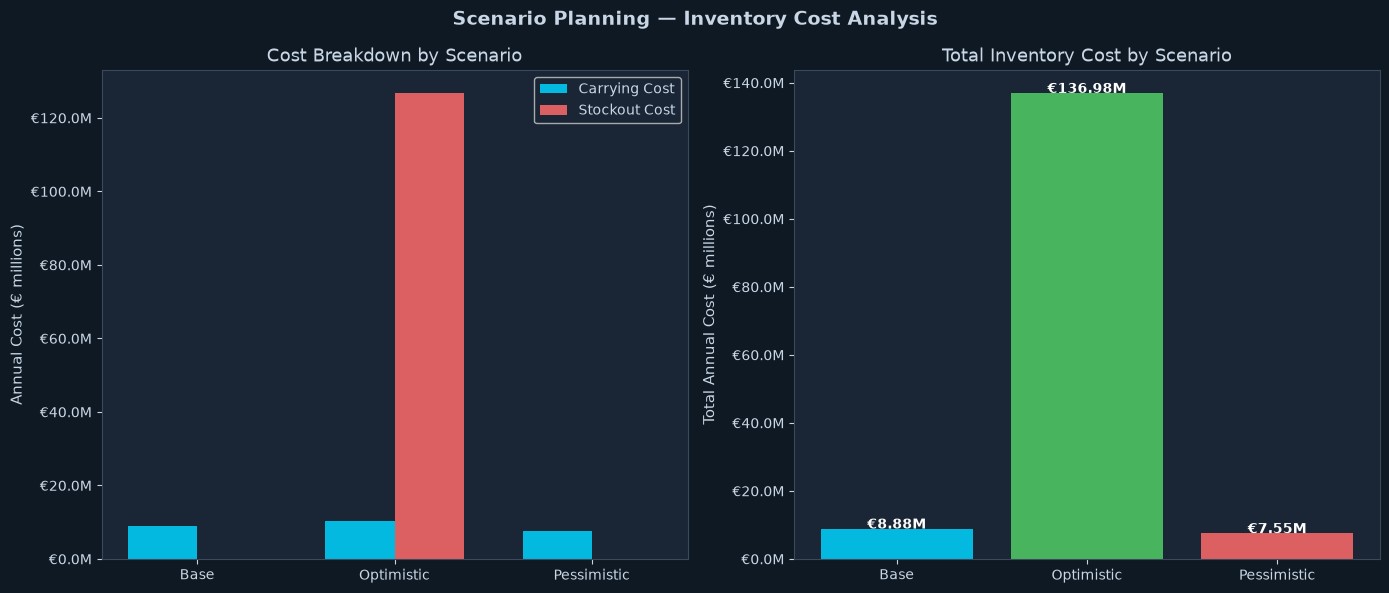

In [7]:
# ============================================================
# CELL 6 — Visualise Scenario Comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Scenario Planning — Inventory Cost Analysis",
             fontsize=14, fontweight="bold")

scenarios     = ["Base","Optimistic","Pessimistic"]
sc_colors     = [ACCENT, ACCENT3, ACCENT2]
carry_vals    = [sc_summary.loc[s,"Carry_Cost"]   / 1e6 for s in scenarios]
stockout_vals = [sc_summary.loc[s,"Stockout_Cost"] / 1e6 for s in scenarios]
total_vals    = [sc_summary.loc[s,"Total_Cost"]    / 1e6 for s in scenarios]

x = np.arange(len(scenarios))
w = 0.35

axes[0].bar(x - w/2, carry_vals,    w, label="Carrying Cost",
            color=ACCENT,  alpha=0.85, edgecolor="none")
axes[0].bar(x + w/2, stockout_vals, w, label="Stockout Cost",
            color=ACCENT2, alpha=0.85, edgecolor="none")
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenarios)
axes[0].set_title("Cost Breakdown by Scenario")
axes[0].set_ylabel("Annual Cost (€ millions)")
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"€{v:.1f}M"))

axes[1].bar(scenarios, total_vals,
            color=sc_colors, alpha=0.85, edgecolor="none")
axes[1].set_title("Total Inventory Cost by Scenario")
axes[1].set_ylabel("Total Annual Cost (€ millions)")
for i, val in enumerate(total_vals):
    axes[1].text(i, val + 0.05, f"€{val:.2f}M",
                 ha="center", fontsize=10, color="white", fontweight="bold")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"€{v:.1f}M"))

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/inventory/scenario_comparison.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

In [8]:
# ============================================================
# CELL 7 — ABC-XYZ Driven Inventory Policy Matrix
# ============================================================

policy_matrix = {
    ("A","X"): "Lean automated reordering. Weekly cycle. 99% SL.",
    ("A","Y"): "Safety stock + promo buffer. Weekly review. 99% SL.",
    ("A","Z"): "High safety stock. Manual planner oversight. 99% SL.",
    ("B","X"): "Standard automated. Fortnightly cycle. 95% SL.",
    ("B","Y"): "Standard + variability buffer. Fortnightly. 95% SL.",
    ("B","Z"): "Elevated SS. Weekly exception review. 95% SL.",
    ("C","X"): "Min-max automated. Monthly review. 90% SL.",
    ("C","Y"): "Min-max + buffer. Monthly review. 90% SL.",
    ("C","Z"): "Consider rationalising. Monthly review. 90% SL.",
}

store_stats["Inventory_Policy"] = store_stats.apply(
    lambda r: policy_matrix.get(
        (r["ABC_Class"], r["XYZ_Class"]),
        "Standard automated. 90% SL."
    ), axis=1
)

print("ABC-XYZ INVENTORY POLICY MATRIX")
print("=" * 65)
for (abc, xyz), policy in policy_matrix.items():
    count = len(store_stats[(store_stats["ABC_Class"]==abc)
                            & (store_stats["XYZ_Class"]==xyz)])
    print(f"  [{abc}{xyz}] {count:3d} stores → {policy}")

ABC-XYZ INVENTORY POLICY MATRIX
  [AX]  66 stores → Lean automated reordering. Weekly cycle. 99% SL.
  [AY] 709 stores → Safety stock + promo buffer. Weekly review. 99% SL.
  [AZ]   0 stores → High safety stock. Manual planner oversight. 99% SL.
  [BX]  12 stores → Standard automated. Fortnightly cycle. 95% SL.
  [BY] 223 stores → Standard + variability buffer. Fortnightly. 95% SL.
  [BZ]   0 stores → Elevated SS. Weekly exception review. 95% SL.
  [CX]   5 stores → Min-max automated. Monthly review. 90% SL.
  [CY]  98 stores → Min-max + buffer. Monthly review. 90% SL.
  [CZ]   2 stores → Consider rationalising. Monthly review. 90% SL.


TOP 10 STORES BY IMPROVEMENT POTENTIAL
      Store ABC_Class XYZ_Class  Store_MAPE  Annual_Cost_Saving
Rank                                                           
1       817         A         Y    9.212845        48267.655461
2       262         A         Y    7.612657        45624.380969
3      1114         A         X    7.575149        45500.137882
4       251         A         X    6.614604        42365.774751
5       513         A         X    7.680674        40542.713601
6       842         A         Y    7.680674        39989.700258
7       562         A         X    7.680674        39931.336064
8       788         A         X    7.680674        39687.867663
9       383         A         X    7.680674        38572.280989
10      756         A         Y    7.680674        36185.952376


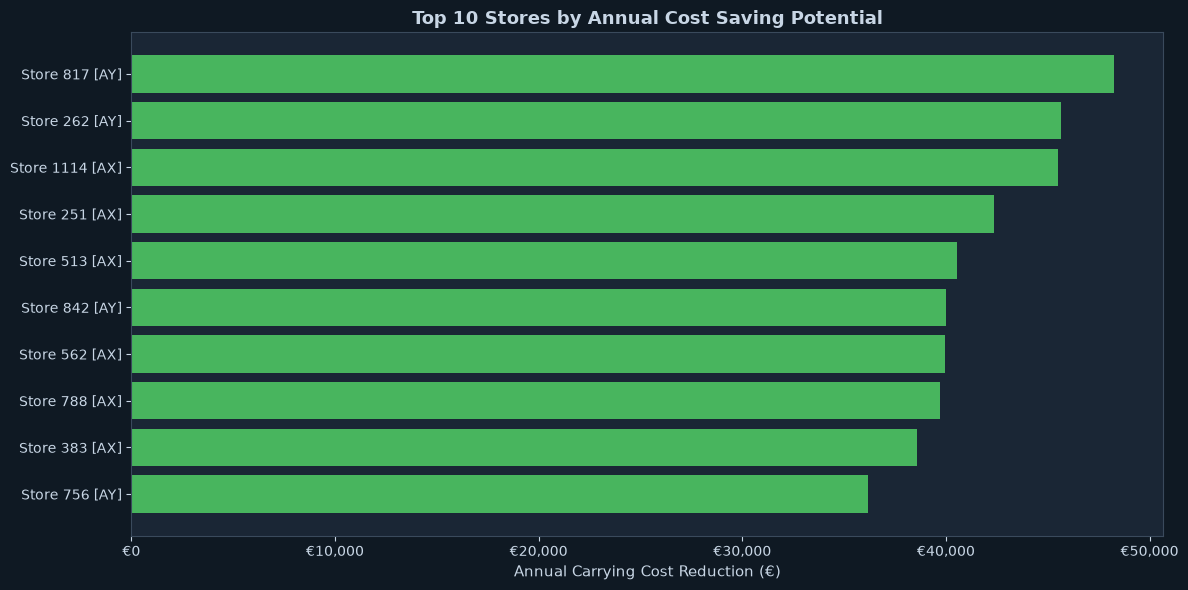

In [9]:
# ============================================================
# CELL 8 — Top 10 Improvement Opportunities
# ============================================================
# Which stores will benefit MOST from better forecasting?
# Ranked by: annual cost saving potential
# These are the stores that get priority attention in the
# implementation roadmap.
# ============================================================

top10 = (store_stats
         .nlargest(10, "Annual_Cost_Saving")
         [["Store","ABC_Class","XYZ_Class","Avg_Daily_Sales",
           "Store_MAPE","Current_SS_Cost","Annual_SS_Cost",
           "Annual_Cost_Saving","Inventory_Policy"]]
         .reset_index(drop=True))
top10.index = top10.index + 1
top10.index.name = "Rank"

print("TOP 10 STORES BY IMPROVEMENT POTENTIAL")
print("=" * 70)
print(top10[["Store","ABC_Class","XYZ_Class",
             "Store_MAPE","Annual_Cost_Saving"]].to_string())

fig, ax = plt.subplots(figsize=(12, 6))
colors_top = [ACCENT3 if cls=="A"
              else ACCENT4 if cls=="B"
              else ACCENT2
              for cls in top10["ABC_Class"]]
bars = ax.barh(
    [f"Store {s} [{a}{x}]" for s,a,x in
     zip(top10["Store"], top10["ABC_Class"], top10["XYZ_Class"])],
    top10["Annual_Cost_Saving"],
    color=colors_top, alpha=0.85, edgecolor="none"
)
ax.set_title("Top 10 Stores by Annual Cost Saving Potential",
             fontweight="bold")
ax.set_xlabel("Annual Carrying Cost Reduction (€)")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}"))
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/inventory/top10_opportunities.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()

In [10]:
# ============================================================
# CELL 9 — Export Everything for Power BI
# ============================================================

# Inventory policy table
store_stats.to_csv(
    f"{POWERBI_EXPORT_DIR}/pb_inventory_policy.csv", index=False)

# Scenario analysis
scenario_df.to_csv(
    f"{POWERBI_EXPORT_DIR}/pb_scenario_analysis.csv", index=False)

# Top 10 opportunities
top10.to_csv(
    f"{POWERBI_EXPORT_DIR}/pb_top10_opportunities.csv", index=False)

# KPI summary card for Power BI
kpi_summary = pd.DataFrame([{
    "Total_Stores"            : len(store_stats),
    "Overall_MAPE"            : round(store_mape["Store_MAPE"].mean(), 1),
    "Total_Current_SS_Cost"   : round(total_current_ss_cost, 0),
    "Total_Recommended_SS_Cost": round(total_recommend_ss_cost, 0),
    "Total_Annual_Saving"     : round(total_saving, 0),
    "Saving_Pct"              : round(total_saving/total_current_ss_cost*100, 1),
    "A_Class_Stores"          : len(store_stats[store_stats["ABC_Class"]=="A"]),
    "B_Class_Stores"          : len(store_stats[store_stats["ABC_Class"]=="B"]),
    "C_Class_Stores"          : len(store_stats[store_stats["ABC_Class"]=="C"]),
}])
kpi_summary.to_csv(
    f"{POWERBI_EXPORT_DIR}/pb_kpi_summary.csv", index=False)

print("All Phase 9 exports complete:")
for f in ["pb_inventory_policy.csv","pb_scenario_analysis.csv",
          "pb_top10_opportunities.csv","pb_kpi_summary.csv"]:
    print(f"  → {POWERBI_EXPORT_DIR}/{f}")

All Phase 9 exports complete:
  → C:\Users\Devanshi\dfsc\outputs\powerbi/pb_inventory_policy.csv
  → C:\Users\Devanshi\dfsc\outputs\powerbi/pb_scenario_analysis.csv
  → C:\Users\Devanshi\dfsc\outputs\powerbi/pb_top10_opportunities.csv
  → C:\Users\Devanshi\dfsc\outputs\powerbi/pb_kpi_summary.csv
